In [ ]:
#Load, Profile and Save Dataset

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

# Load Titanic dataset exactly once
df = sns.load_dataset("titanic")

# Immediately save offline fallback
df.to_csv("titanic.csv", index=False)

print("Dataset loaded successfully.")
print("Offline copy saved as titanic.csv")

# Dataset information
print("\n========== INFO ==========")
df.info()

# Descriptive statistics
print("\n========== DESCRIBE ==========")
print(df.describe(include="all"))

# Shape
print("\n========== SHAPE ==========")
print(df.shape)

# Missing-value percentage
print("\n========== MISSING VALUE PERCENTAGE ==========")

missing_percent = df.isnull().mean() * 100
missing_percent = missing_percent[missing_percent > 0]

print(missing_percent.sort_values(ascending=False))

Dataset loaded successfully.
Offline copy saved as titanic.csv

========== INFO ==========
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usag

In [ ]:
# MISSING VALUES

print("========== MISSING VALUES BEFORE CLEANING ==========")

missing_percentage = df.isnull().mean() * 100
missing_percentage = missing_percentage[missing_percentage > 0]

print(missing_percentage)

# Columns with more than 30% missing

high_missing_columns = [
    col for col in missing_percentage.index
    if missing_percentage[col] > 30
]

print("\nColumns with >30% missing:")
print(high_missing_columns)

# Drop highly missing columns
df.drop(columns=high_missing_columns, inplace=True)

# Columns with 5% - 30% missing

medium_missing_columns = [
    col for col in missing_percentage.index
    if 5 <= missing_percentage[col] <= 30
]

print("\nColumns with 5%-30% missing:")
print(medium_missing_columns)

# Impute age using median
if "age" in medium_missing_columns:
    df["age"] = df["age"].fillna(df["age"].median())

# Columns with <5% missing

low_missing_columns = [
    col for col in missing_percentage.index
    if missing_percentage[col] < 5
]

print("\nColumns with <5% missing:")
print(low_missing_columns)

# Drop rows containing low-percentage missing values
if low_missing_columns:
    df.dropna(subset=low_missing_columns, inplace=True)

# Remove target leakage
if "alive" in df.columns:
    df.drop(columns=["alive"], inplace=True)

# Reset index
df.reset_index(drop=True, inplace=True)

print("\n========== AFTER CLEANING ==========")
print("Shape:", df.shape)

print("\nRemaining Missing Values:")
print(df.isnull().sum())

# Save cleaned dataset for modeling
df.to_csv("titanic.csv", index=False)

print("\nCleaned dataset saved to titanic.csv")

========== MISSING VALUES BEFORE CLEANING ==========
age            19.865320
embarked        0.224467
deck           77.216611
embark_town     0.224467
dtype: float64

Columns with >30% missing:
['deck']

Columns with 5%-30% missing:
['age']

Columns with <5% missing:
['embarked', 'embark_town']

========== AFTER CLEANING ==========
Shape: (889, 13)

Remaining Missing Values:
survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alone          0
dtype: int64

Cleaned dataset saved to titanic.csv


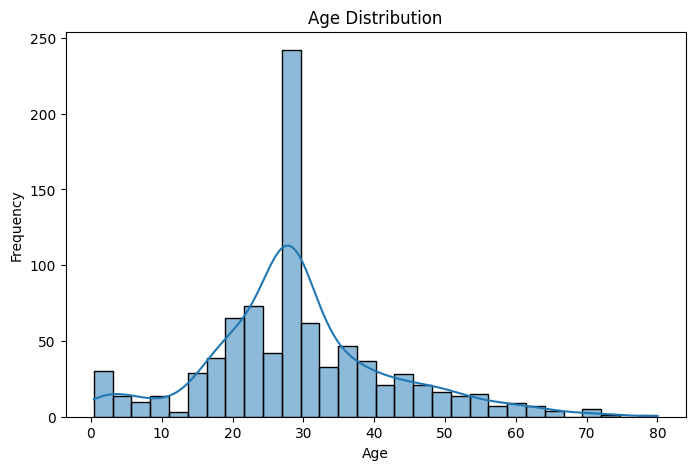

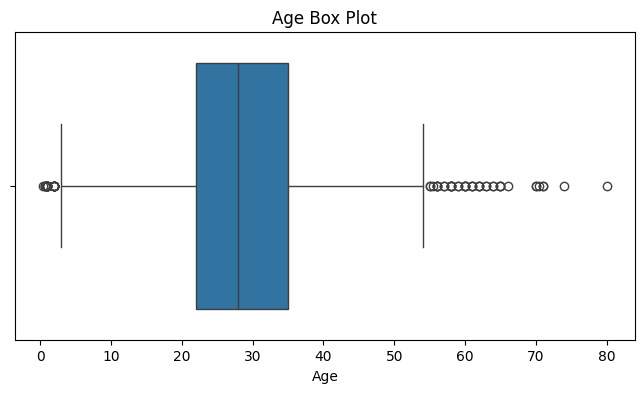

In [ ]:
# Univariate Analysis

# Age Histogram
plt.figure(figsize=(8, 5))

sns.histplot(
    df["age"],
    bins=30,
    kde=True
)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()


# Age Box Plot
plt.figure(figsize=(8, 4))

sns.boxplot(
    x=df["age"]
)

plt.title("Age Box Plot")
plt.xlabel("Age")
plt.show()

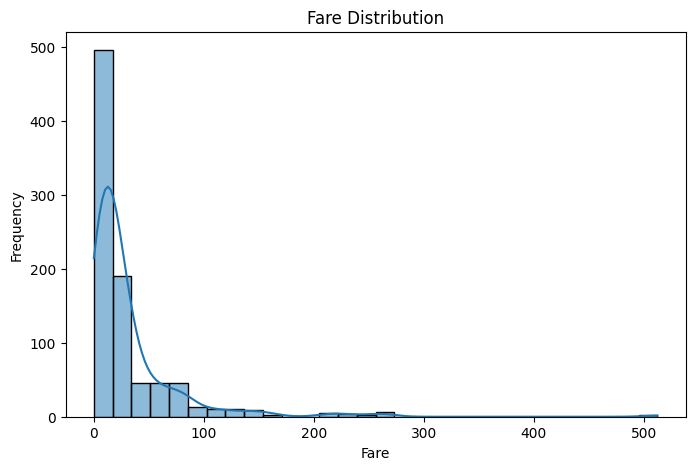

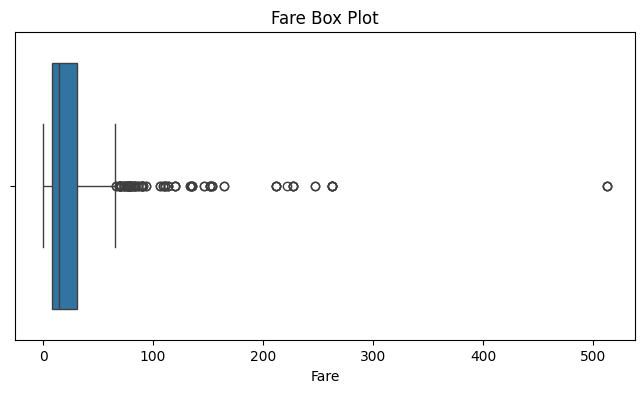

In [ ]:
# Fare Histogram
plt.figure(figsize=(8, 5))

sns.histplot(
    df["fare"],
    bins=30,
    kde=True
)

plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Frequency")
plt.show()


# Fare Box Plot
plt.figure(figsize=(8, 4))

sns.boxplot(
    x=df["fare"]
)

plt.title("Fare Box Plot")
plt.xlabel("Fare")
plt.show()

In [ ]:
# IQR Outlier Detection

def find_iqr_outliers(data, column):

    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[
        (data[column] < lower_bound) |
        (data[column] > upper_bound)
    ]

    return Q1, Q3, IQR, lower_bound, upper_bound, len(outliers)


for column in ["age", "fare"]:

    Q1, Q3, IQR, lower, upper, count = find_iqr_outliers(
        df,
        column
    )

    print("\n", column.upper())

    print("Q1:", Q1)
    print("Q3:", Q3)
    print("IQR:", IQR)
    print("Lower Bound:", lower)
    print("Upper Bound:", upper)
    print("Number of Outliers:", count)


 AGE
Q1: 22.0
Q3: 35.0
IQR: 13.0
Lower Bound: 2.5
Upper Bound: 54.5
Number of Outliers: 65

 FARE
Q1: 7.8958
Q3: 31.0
IQR: 23.1042
Lower Bound: -26.7605
Upper Bound: 65.6563
Number of Outliers: 114


In [ ]:
# Fare Mean, Median and Mode

# FARE STATISTICS

fare_mean = df["fare"].mean()
fare_median = df["fare"].median()
fare_mode = df["fare"].mode()[0]

print("Fare Mean:", fare_mean)
print("Fare Median:", fare_median)
print("Fare Mode:", fare_mode)

print("\nOrdering:")

if fare_mean > fare_median > fare_mode:

    print("Mean > Median > Mode")
    print("Conclusion: Fare distribution is right-skewed.")

elif fare_mean < fare_median < fare_mode:

    print("Mean < Median < Mode")
    print("Conclusion: Fare distribution is left-skewed.")

else:

    print("No strong mean-median-mode skew ordering.")

Fare Mean: 32.09668087739032
Fare Median: 14.4542
Fare Mode: 8.05

Ordering:
Mean > Median > Mode
Conclusion: Fare distribution is right-skewed.


In [ ]:
# Bivariate Analysis and Correlation
print("------------------------")
# Survival Rate by Sex
print("------------------------")
survival_by_sex = (
    df.groupby("sex")["survived"]
    .mean()
    .mul(100)
)

print("Survival Rate by Sex:")
print(survival_by_sex)
print("------------------------")
# Survival Rate by Passenger Class
print("------------------------")
survival_by_pclass = (
    df.groupby("pclass")["survived"]
    .mean()
    .mul(100)
)

print("Survival Rate by Passenger Class:")
print(survival_by_pclass)
print("------------------------")
# Survival by Sex and Class
print("------------------------")
survival_by_sex_pclass = (
    df.groupby(["sex", "pclass"])["survived"]
    .mean()
    .mul(100)
)

print("Survival Rate by Sex and Passenger Class:")
print(survival_by_sex_pclass)

------------------------
------------------------
Survival Rate by Sex:
sex
female    74.038462
male      18.890815
Name: survived, dtype: float64
------------------------
------------------------
Survival Rate by Passenger Class:
pclass
1    62.616822
2    47.282609
3    24.236253
Name: survived, dtype: float64
------------------------
------------------------
Survival Rate by Sex and Passenger Class:
sex     pclass
female  1         96.739130
        2         92.105263
        3         50.000000
male    1         36.885246
        2         15.740741
        3         13.544669
Name: survived, dtype: float64


In [ ]:
# Boolean Masking
# Female passengers in different classes

female_first = df[
    (df["sex"] == "female") &
    (df["pclass"] == 1)
]

female_second = df[
    (df["sex"] == "female") &
    (df["pclass"] == 2)
]

female_third = df[
    (df["sex"] == "female") &
    (df["pclass"] == 3)
]

# Male passengers in different classes

male_first = df[
    (df["sex"] == "male") &
    (df["pclass"] == 1)
]

male_second = df[
    (df["sex"] == "male") &
    (df["pclass"] == 2)
]

male_third = df[
    (df["sex"] == "male") &
    (df["pclass"] == 3)
]

print("Female 1st:", female_first["survived"].mean())
print("Female 2nd:", female_second["survived"].mean())
print("Female 3rd:", female_third["survived"].mean())

print("Male 1st:", male_first["survived"].mean())
print("Male 2nd:", male_second["survived"].mean())
print("Male 3rd:", male_third["survived"].mean())

Female 1st: 0.967391304347826
Female 2nd: 0.9210526315789473
Female 3rd: 0.5
Male 1st: 0.36885245901639346
Male 2nd: 0.1574074074074074
Male 3rd: 0.13544668587896252


In [ ]:
# Correlation Matrix
correlation_columns = [
    "survived",
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"
]

corr_matrix = df[correlation_columns].corr()

print(corr_matrix)

          survived    pclass       age     sibsp     parch      fare
survived  1.000000 -0.335549 -0.069822 -0.034040  0.083151  0.255290
pclass   -0.335549  1.000000 -0.336512  0.081656  0.016824 -0.548193
age      -0.069822 -0.336512  1.000000 -0.232543 -0.171485  0.093707
sibsp    -0.034040  0.081656 -0.232543  1.000000  0.414542  0.160887
parch     0.083151  0.016824 -0.171485  0.414542  1.000000  0.217532
fare      0.255290 -0.548193  0.093707  0.160887  0.217532  1.000000


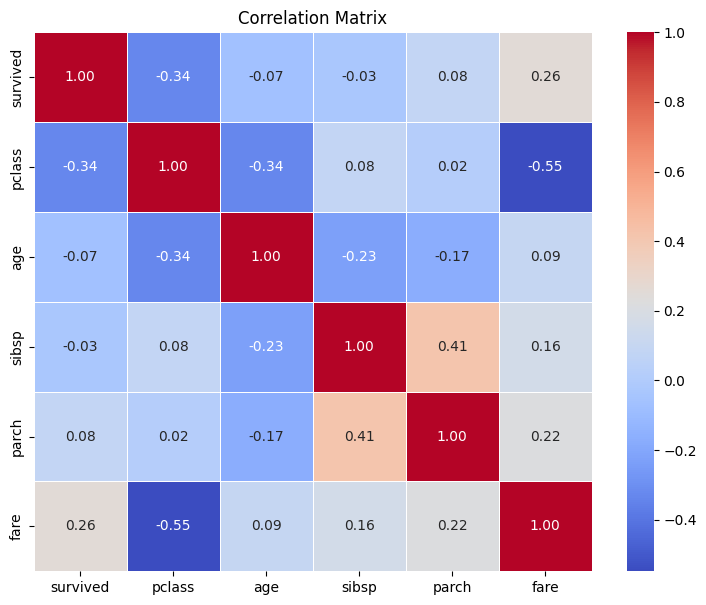

In [ ]:
# Heatmap
plt.figure(figsize=(9, 7))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Matrix")
plt.show()

In [ ]:
# Two Strongest Correlations
# Get upper triangle only
upper_triangle = corr_matrix.where(
    np.triu(
        np.ones(corr_matrix.shape),
        k=1
    ).astype(bool)
)

correlation_pairs = upper_triangle.stack()

strongest_two = (
    correlation_pairs
    .abs()
    .sort_values(ascending=False)
    .head(2)
)

print("========== TWO STRONGEST CORRELATIONS ==========")

for pair in strongest_two.index:

    value = correlation_pairs[pair]

    print(
        f"{pair[0]} <-> {pair[1]} = {value:.4f}"
    )

========== TWO STRONGEST CORRELATIONS ==========
pclass <-> fare = -0.5482
sibsp <-> parch = 0.4145


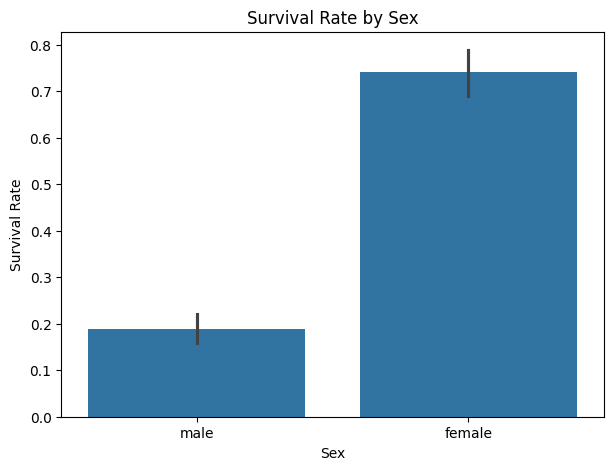

In [ ]:
# Multivariate Analysis

# Chart 1 — Survival by Sex
plt.figure(figsize=(7, 5))

sns.barplot(
    data=df,
    x="sex",
    y="survived"
)

plt.title("Survival Rate by Sex")
plt.xlabel("Sex")
plt.ylabel("Survival Rate")
plt.show()

**Interpretation:**
The chart shows a clear difference in survival rates between male and female passengers. Female passengers have a higher observed survival rate than male passengers, indicating that sex is strongly associated with survival in this dataset.

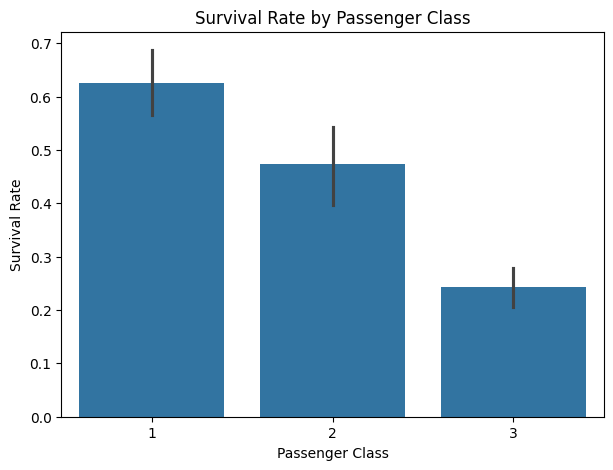

In [ ]:
# Chart 2 — Survival by Passenger Class
plt.figure(figsize=(7, 5))

sns.barplot(
    data=df,
    x="pclass",
    y="survived"
)

plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.show()

**Interpretation:**
Survival rates differ across passenger classes. First-class passengers show a higher observed survival rate, while third-class passengers show a lower rate.

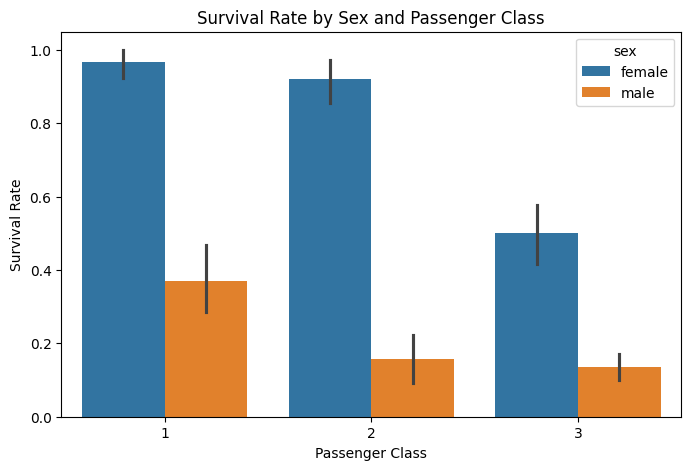

In [ ]:
# Chart 3 — Sex + Passenger Class
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="pclass",
    y="survived",
    hue="sex"
)

plt.title("Survival Rate by Sex and Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.show()

**Interpretation:**
The combination of sex and passenger class provides more detailed information than either variable alone. Survival rates vary substantially across the sex-class groups, showing that these features jointly describe differences in observed survival.

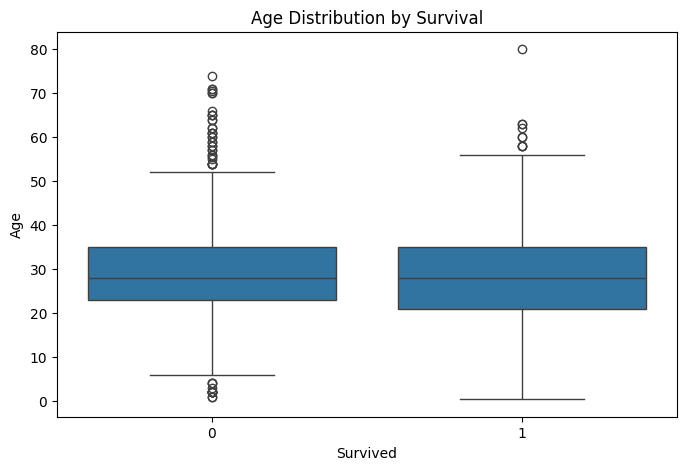

In [ ]:
# Chart 4 — Age vs Survival

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="survived",
    y="age"
)

plt.title("Age Distribution by Survival")
plt.xlabel("Survived")
plt.ylabel("Age")
plt.show()

**Interpretation:**
The box plot compares the age distributions of passengers who survived and those who did not. The distributions overlap considerably, suggesting that age alone does not completely separate the two survival groups.

In [ ]:
# Standardization for EDA
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_standardized = df.copy()

df_standardized[
    ["age_z", "fare_z"]
] = scaler.fit_transform(
    df[["age", "fare"]]
)

print("========== BEFORE STANDARDIZATION ==========")

print(
    df[["age", "fare"]]
    .agg(["mean", "std"])
)

print("\n========== AFTER STANDARDIZATION ==========")

print(
    df_standardized[["age_z", "fare_z"]]
    .agg(["mean", "std"])
)

========== BEFORE STANDARDIZATION ==========
            age       fare
mean  29.315152  32.096681
std   12.984932  49.697504

========== AFTER STANDARDIZATION ==========
             age_z        fare_z
mean  2.717486e-16  1.398706e-16
std   1.000563e+00  1.000563e+00
